In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import pickle
import pandas as pd
import uproot
import awkward as ak
import tabulate as tab
import glob
import h5py
from tqdm import tqdm

from scipy.signal import find_peaks


# Find peaks

In [2]:
# ---------- helpers ----------
def estimate_baseline_chunks(record: np.ndarray, chunk: int = 2000, q: float = 10.0) -> np.ndarray:
    """Robust baseline per chunk using percentile q."""
    n = len(record)
    return np.asarray(
        [np.percentile(record[i:i + chunk], q) for i in range(0, n, chunk)],
        dtype=np.float64
    )

def chunks_to_trace(baseline_chunks: np.ndarray, n_samples: int, chunk: int) -> np.ndarray:
    """Interpolate chunk baselines to a per-sample baseline trace."""
    centers = np.arange(len(baseline_chunks), dtype=np.float64) * chunk + (chunk - 1) / 2
    centers = np.clip(centers, 0, n_samples - 1)
    return np.interp(np.arange(n_samples, dtype=np.float64), centers, baseline_chunks)

def constant_fraction_crossing_index(y: np.ndarray, peak_idx: int, frac: float = 0.2, search_back: int = 400):
    """First rising-edge crossing of frac*peak height. Returns int index or None."""
    peak_val = y[peak_idx]
    if peak_val <= 0:
        return None
    thr = frac * peak_val
    start = max(0, peak_idx - search_back)
    seg = y[start:peak_idx + 1]
    above = seg >= thr
    if not np.any(above):
        return None
    k = int(np.argmax(above))
    return int(start + k)

def local_max(arr: np.ndarray, idx: int, pad: int = 2) -> float:
    lo = max(0, idx - pad)
    hi = min(len(arr), idx + pad + 1)
    return float(np.max(arr[lo:hi]))


# ---------- main ----------
def build_pulse_dataset_from_X(
    X: np.ndarray,
    *,
    pre: int = 40,
    post: int = 216,

    # Baseline
    baseline_chunk: int = 2000,
    baseline_q: float = 10.0,
    drift_ptp_threshold: float = 200.0,

    # Peak detection on baseline-subtracted waveform
    height: float = 80.0,
    prominence: float = 150.0,
    distance: int = 150,

    # Alignment
    use_pos: str = "align",      # "align" (CFD) or "argmax"
    align_frac: float = 0.2,
    align_search_back: int = 400,
    drop_failed_align: bool = True,

    # Cuts
    ADCsat: float | None = None,      # drop pulses if peak_raw_localmax >= ADCsat
    peak_raw_pad: int = 2,            # local max pad for raw peak
    amp_min: float | None = None,     # cut on baseline-subtracted peak height at argmax
    amp_max: float | None = None,

    # Record filter
    skip_flagged_records: bool = False,

    # Storage
    store_raw_window: bool = True,
    store_sub_window: bool = True,
    store_baseline_trace: bool = False,   # usually False (big); enable for debugging
    dtype=np.float32,
):
    """
    Builds a pulse-level dataset directly from X, no 'results' needed.

    Returns dict with keys:
      pulses_raw: (N,L) raw windows (optional)
      pulses_sub: (N,L) baseline-sub windows (optional)
      record_index: (N,)
      pos: (N,) window center index (align_idx or peak_idx)
      peak_idx: (N,) argmax index in trigger
      align_idx: (N,) CFD crossing index (or -1)
      peak_sub: (N,) baseline-sub peak height at argmax
      peak_raw: (N,) raw ADC at argmax sample
      peak_raw_localmax: (N,) raw local max around argmax (pad=peak_raw_pad)
      drift_ptp: (N_records,) per-record drift ptp
      flagged_drift: (N_records,) per-record flag
      (optional) baseline_trace_per_record: list of arrays if store_baseline_trace=True
    """
    use_pos = str(use_pos).strip().lower()
    if use_pos not in ("align", "argmax"):
        raise ValueError("use_pos must be 'align' or 'argmax'")

    n_records, n_samples = X.shape
    L = pre + post

    # Per-record diagnostics
    drift_ptp_arr = np.zeros(n_records, dtype=np.float32)
    flagged_arr = np.zeros(n_records, dtype=bool)
    baseline_traces = [] if store_baseline_trace else None

    # Pulse-level outputs
    pulses_raw = []
    pulses_sub = []
    record_index = []
    pos_used = []
    peak_idx_list = []
    align_idx_list = []
    peak_sub_list = []
    peak_raw_list = []
    peak_raw_lmax_list = []

    for r in range(n_records):
        rec = X[r].astype(np.float64, copy=False)

        # Baseline estimate
        bchunks = estimate_baseline_chunks(rec, chunk=baseline_chunk, q=baseline_q)
        drift_ptp = float(np.ptp(bchunks)) if len(bchunks) else 0.0
        drift_ptp_arr[r] = drift_ptp
        flagged = drift_ptp > drift_ptp_threshold
        flagged_arr[r] = flagged
        if skip_flagged_records and flagged:
            continue

        btrace = chunks_to_trace(bchunks, n_samples=n_samples, chunk=baseline_chunk)
        if store_baseline_trace:
            baseline_traces.append(btrace.astype(dtype))

        y = rec - btrace

        # Detect peaks (argmax indices)
        pk_idx, props = find_peaks(
            y,
            height=height,
            prominence=prominence,
            distance=distance,
        )
        if pk_idx.size == 0:
            continue

        pk_idx = pk_idx.astype(np.int64)
        pk_sub = props["peak_heights"].astype(np.float64)

        # Raw peak values at argmax and local max
        pk_raw = rec[pk_idx].astype(np.float64)
        pk_raw_lmax = np.asarray([local_max(rec, int(p), pad=peak_raw_pad) for p in pk_idx], dtype=np.float64)

        # CFD alignment indices (same length as pk_idx)
        al_idx = np.full(len(pk_idx), -1, dtype=np.int64)
        for i, p in enumerate(pk_idx):
            a = constant_fraction_crossing_index(y, int(p), frac=align_frac, search_back=align_search_back)
            al_idx[i] = -1 if a is None else int(a)

        # Build ONE keep mask for all per-peak arrays
        keep = np.ones(len(pk_idx), dtype=bool)

        if use_pos == "align":
            if drop_failed_align:
                keep &= (al_idx >= 0)

        if ADCsat is not None:
            keep &= (pk_raw_lmax < float(ADCsat))

        if amp_min is not None:
            keep &= (pk_sub >= float(amp_min))
        if amp_max is not None:
            keep &= (pk_sub <= float(amp_max))

        pk_idx = pk_idx[keep]
        pk_sub = pk_sub[keep]
        pk_raw = pk_raw[keep]
        pk_raw_lmax = pk_raw_lmax[keep]
        al_idx = al_idx[keep]

        if pk_idx.size == 0:
            continue

        # Choose window center index
        pos = al_idx if use_pos == "align" else pk_idx

        # Extract windows
        for p_center, p_peak, a_idx, ps, pr, prl in zip(pos, pk_idx, al_idx, pk_sub, pk_raw, pk_raw_lmax):
            if p_center < 0:
                continue
            start = int(p_center) - pre
            end = int(p_center) + post
            if start < 0 or end > n_samples:
                continue

            # sanity: peak index should land in this window for normal pulses
            # (if it doesn't, skip to avoid mismatched metadata)
            if not (start <= int(p_peak) < end):
                continue

            if store_raw_window:
                pulses_raw.append(rec[start:end])
            if store_sub_window:
                pulses_sub.append(y[start:end])

            record_index.append(r)
            pos_used.append(int(p_center))
            peak_idx_list.append(int(p_peak))
            align_idx_list.append(int(a_idx))
            peak_sub_list.append(float(ps))
            peak_raw_list.append(float(pr))
            peak_raw_lmax_list.append(float(prl))

    out = {
        "record_index": np.asarray(record_index, dtype=np.int32),
        "pos": np.asarray(pos_used, dtype=np.int32),
        "peak_idx": np.asarray(peak_idx_list, dtype=np.int32),
        "align_idx": np.asarray(align_idx_list, dtype=np.int32),
        "peak_sub": np.asarray(peak_sub_list, dtype=dtype),
        "peak_raw": np.asarray(peak_raw_list, dtype=dtype),
        "peak_raw_localmax": np.asarray(peak_raw_lmax_list, dtype=dtype),
        "pre": int(pre),
        "post": int(post),
        "L": int(L),
        "use_pos": use_pos,
        "align_frac": float(align_frac),
        "baseline_chunk": int(baseline_chunk),
        "baseline_q": float(baseline_q),
        "height": float(height),
        "prominence": float(prominence),
        "distance": int(distance),
        "drift_ptp_per_record": drift_ptp_arr,
        "flagged_drift_per_record": flagged_arr,
    }

    if store_raw_window:
        out["pulses_raw"] = np.asarray(pulses_raw, dtype=dtype)
    if store_sub_window:
        out["pulses_sub"] = np.asarray(pulses_sub, dtype=dtype)
    if store_baseline_trace:
        out["baseline_trace_per_record"] = baseline_traces  # list of arrays

    return out

# Plots

In [3]:
def plot_pulses(
    pulse_ds,
    *,
    pre: int | None = None,
    post: int | None = None,
    use_waveform: str = "sub",        # "sub" or "raw"
    ADCsat: float | None = None,
    sat_source: str = "peak_raw_localmax",  # "peak_raw_localmax" (preferred) or "peak_raw"

    # position cut in trigger record
    use_pos: str = "align",           # "align" or "argmax" (uses align_idx or peak_idx)
    pos_side: str = "before",         # "before", "after", "between", "none"
    pos_cut=20000,                    # int or (lo,hi)

    # amplitude cut (baseline-subtracted or raw, depending on amp_source)
    amp_side: str = "none",           # "below", "above", "between", "none"
    amp_cut=500.0,                    # float or (lo,hi)
    amp_source: str = "peak_sub",     # "peak_sub" or "peak_raw" or "peak_raw_localmax"

    # plotting options
    max_pulses_to_plot: int | None = 2000,
    show_mean_band: bool = True,
):
    """
    Select pulses from pulse_ds using cuts on position + amplitude (+ optional saturation),
    plot superposition on left and mean (±std) on right.

    Returns:
      windows: (N_selected, L) selected waveforms (raw or sub)
      meta: dict with record_index, pos, peak_sub, peak_raw, peak_idx, align_idx
    """
    assert use_pos in ("align", "argmax")
    assert pos_side in ("before", "after", "between", "none")
    assert amp_side in ("below", "above", "between", "none")
    assert use_waveform in ("sub", "raw")

    # Infer window length from pulse_ds
    if pre is None: pre = int(pulse_ds.get("pre", 0))
    if post is None: post = int(pulse_ds.get("post", 0))
    L = int(pulse_ds.get("L", pre + post))
    if L <= 0:
        # fallback to waveform shape
        wf_key = "pulses_sub" if use_waveform == "sub" else "pulses_raw"
        L = pulse_ds[wf_key].shape[1]

    # Choose waveform array
    wf_key = "pulses_sub" if use_waveform == "sub" else "pulses_raw"
    if wf_key not in pulse_ds:
        raise KeyError(f"pulse_ds has no '{wf_key}'. Available keys: {list(pulse_ds.keys())}")
    W = np.asarray(pulse_ds[wf_key])

    # Choose position array in trigger record (not relative window)
    pos_arr = np.asarray(pulse_ds["align_idx"] if use_pos == "align" else pulse_ds["peak_idx"], dtype=np.int64)

    # Amplitude source
    if amp_source not in pulse_ds:
        raise KeyError(f"amp_source='{amp_source}' not found in pulse_ds")
    amp_arr = np.asarray(pulse_ds[amp_source], dtype=np.float64)

    # Saturation source
    if ADCsat is not None:
        if sat_source not in pulse_ds:
            raise KeyError(f"sat_source='{sat_source}' not found in pulse_ds")
        sat_arr = np.asarray(pulse_ds[sat_source], dtype=np.float64)

    # ---- selection mask ----
    mask = np.ones(len(pos_arr), dtype=bool)

    # valid align indices if requested
    if use_pos == "align":
        mask &= (pos_arr >= 0)

    # position cut
    if pos_side != "none":
        if pos_side == "before":
            mask &= (pos_arr < int(pos_cut))
        elif pos_side == "after":
            mask &= (pos_arr > int(pos_cut))
        else:  # between
            lo, hi = pos_cut
            mask &= (pos_arr >= int(lo)) & (pos_arr <= int(hi))

    # amplitude cut
    if amp_side != "none":
        if amp_side == "below":
            mask &= (amp_arr < float(amp_cut))
        elif amp_side == "above":
            mask &= (amp_arr > float(amp_cut))
        else:  # between
            lo, hi = amp_cut
            mask &= (amp_arr >= float(lo)) & (amp_arr <= float(hi))

    # saturation cut
    if ADCsat is not None:
        mask &= (sat_arr < float(ADCsat))

    idx_sel = np.where(mask)[0]
    if idx_sel.size == 0:
        print("No pulses matched the selection (try changing cuts).")
        return np.empty((0, L)), {}

    windows = W[idx_sel]

    # meta (helpful to inspect)
    meta = {
        "index": idx_sel.astype(np.int32),
        "record_index": np.asarray(pulse_ds["record_index"])[idx_sel].astype(np.int32),
        "pos": np.asarray(pulse_ds.get("pos", pos_arr))[idx_sel].astype(np.int32),
        "peak_idx": np.asarray(pulse_ds.get("peak_idx", pos_arr))[idx_sel].astype(np.int32),
        "align_idx": np.asarray(pulse_ds.get("align_idx", -np.ones(len(pos_arr))))[idx_sel].astype(np.int32),
    }
    for k in ("peak_sub", "peak_raw", "peak_raw_localmax"):
        if k in pulse_ds:
            meta[k] = np.asarray(pulse_ds[k])[idx_sel]

    # downsample for plotting only
    windows_plot = windows
    if max_pulses_to_plot is not None and len(windows) > max_pulses_to_plot:
        take = np.random.choice(len(windows), size=max_pulses_to_plot, replace=False)
        windows_plot = windows[take]

    mean = windows.mean(axis=0)
    std = windows.std(axis=0)

    # ---- plotting (always separate mean panel) ----
    fig, (ax_all, ax_mean) = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)

    t = np.arange(L) - int(pre)  # 0 corresponds to window center

    ax_all.plot(t, windows_plot.T, linewidth=0.6, alpha=0.15)
    ax_all.axvline(0, linestyle="--", linewidth=1)
    ax_all.set_xlabel("Samples relative to window center (0)")
    ax_all.set_ylabel(f"ADC ({'baseline-subtracted' if use_waveform=='sub' else 'raw'})")
    ax_all.grid(True, alpha=0.25)

    ax_mean.plot(t, mean, linewidth=2.0)
    ax_mean.axvline(0, linestyle="--", linewidth=1)
    if show_mean_band:
        ax_mean.fill_between(t, mean - std, mean + std, alpha=0.15)
    ax_mean.set_title("Mean pulse of selection" + (" (±1σ)" if show_mean_band else ""))
    ax_mean.set_xlabel("Samples relative to window center (0)")
    ax_mean.set_ylabel(f"ADC ({'baseline-subtracted' if use_waveform=='sub' else 'raw'})")
    ax_mean.grid(True, alpha=0.25)

    # title text (compact)
    def _pos_txt(side, cut, label):
        side = str(side).strip().lower()
        if side == "none": return f"{label}: none"
        if side == "before": return f"{label} < {cut}"
        if side == "after": return f"{label} > {cut}"
        lo, hi = cut
        return f"{label} in [{lo}, {hi}]"

    def _amp_txt(side, cut, label):
        side = str(side).strip().lower()
        if side == "none": return f"{label}: none"
        if side == "below": return f"{label} < {cut}"
        if side == "above": return f"{label} > {cut}"
        lo, hi = cut
        return f"{label} in [{lo}, {hi}]"

    pos_txt = _pos_txt(pos_side, pos_cut, f"{use_pos}_idx")
    amp_txt = _amp_txt(amp_side, amp_cut, amp_source)
    sat_txt = f"{sat_source}<{ADCsat}" if ADCsat is not None else "sat: none"

    ax_all.set_title(f"Selected pulses | {pos_txt} | {amp_txt} | {sat_txt} | N={len(windows)}")

    plt.show()
    return windows, meta


In [4]:

def plot_peak_position_histogram(
    pulse_ds,
    *,
    use: str = "align",                 # "align" uses align_idx, "argmax" uses peak_idx
    bins: int | np.ndarray = 200,
    range: tuple[int, int] | None = None,
    density: bool = False,
    title: str | None = None,
    ADCsat: float | None = None,
    sat_source: str = "peak_raw_localmax",
):
    """
    Histogram of peak positions across all pulses in pulse_ds.
    Optional saturation cut via sat_source < ADCsat.
    """
    use = str(use).strip().lower()
    if use not in ("align", "argmax"):
        raise ValueError("use must be 'align' or 'argmax'")

    key = "align_idx" if use == "align" else "peak_idx"
    pos = np.asarray(pulse_ds[key], dtype=np.int64)

    mask = np.ones(len(pos), dtype=bool)
    if key == "align_idx":
        mask &= (pos >= 0)

    if ADCsat is not None:
        if sat_source not in pulse_ds:
            raise KeyError(f"sat_source='{sat_source}' not found in pulse_ds")
        mask &= (np.asarray(pulse_ds[sat_source], dtype=np.float64) < float(ADCsat))

    pos = pos[mask]
    if pos.size == 0:
        print("No positions to plot after cuts.")
        return pos

    fig, ax = plt.subplots(1, 1, figsize=(10, 4), constrained_layout=True)
    ax.hist(pos, bins=bins, range=range, density=density)
    ax.set_xlabel(f"Peak position in trigger (sample index) [{key}]")
    ax.set_ylabel("Density" if density else "Count")
    ax.grid(True, alpha=0.25)

    if title is None:
        title = f"Histogram of peak positions ({key}), N={len(pos)}"
        if ADCsat is not None:
            title += f" | {sat_source}<{ADCsat}"
    ax.set_title(title)

    plt.show()
    return pos

In [5]:
def _estimate_baseline_trace(record: np.ndarray, *, chunk: int = 2000, q: float = 10.0) -> np.ndarray:
    """Piecewise baseline: qth percentile per chunk, linearly interpolated to all samples."""
    n = len(record)
    # per-chunk baseline estimates
    b = [np.percentile(record[i:i + chunk], q) for i in range(0, n, chunk)]
    b = np.asarray(b, dtype=np.float64)

    # interpolate to full trace
    centers = np.arange(len(b), dtype=np.float64) * chunk + (chunk - 1) / 2
    centers = np.clip(centers, 0, n - 1)
    return np.interp(np.arange(n, dtype=np.float64), centers, b)


def plot_record_qc_from_pulse_ds(
    X,
    pulse_ds,
    *,
    record_index: int,
    marker_use: str = "pos",          # "pos", "align_idx", "peak_idx"
    use_windows: str = "sub",         # "sub" or "raw" windows to superimpose
    max_pulses_to_plot: int | None = 200,

    # baseline estimation (defaults can be pulled from pulse_ds if present)
    baseline_chunk: int | None = None,
    baseline_q: float | None = None,
    show_baseline_overlay: bool = True,

    # window axis cosmetics
    show_window_center_line: bool = True,
):
    """
    QC plot for a single trigger record using pulse_ds:

      Left top: raw record + baseline overlay
      Left bottom: baseline-subtracted record + ✕ markers at selected pulse indices
      Right: superimposed extracted windows for this record (from pulse_ds)

    Returns:
      windows: (n_pulses_in_record, L) windows (raw or sub) from pulse_ds
      idx: indices in pulse_ds for pulses belonging to this record
    """
    marker_use = str(marker_use).strip().lower()
    if marker_use not in ("pos", "align_idx", "peak_idx"):
        raise ValueError("marker_use must be 'pos', 'align_idx', or 'peak_idx'")

    use_windows = str(use_windows).strip().lower()
    if use_windows not in ("sub", "raw"):
        raise ValueError("use_windows must be 'sub' or 'raw'")

    ri = int(record_index)
    rec = np.asarray(X[ri], dtype=np.float64)
    n = len(rec)

    # pull baseline params from pulse_ds if not provided
    if baseline_chunk is None:
        baseline_chunk = int(pulse_ds.get("baseline_chunk", 2000))
    if baseline_q is None:
        baseline_q = float(pulse_ds.get("baseline_q", 10.0))

    # compute baseline and baseline-subtracted trigger record
    baseline = _estimate_baseline_trace(rec, chunk=baseline_chunk, q=baseline_q)
    y = rec - baseline

    # pulses in this record (indices into pulse_ds arrays)
    rec_of_pulse = np.asarray(pulse_ds["record_index"], dtype=np.int32)
    idx = np.where(rec_of_pulse == ri)[0]
    if idx.size == 0:
        print(f"No pulses in pulse_ds for record_index={ri}")
        return np.empty((0, 0)), idx

    # choose marker indices (in trigger record sample index space)
    if marker_use == "pos":
        if "pos" not in pulse_ds:
            raise KeyError("pulse_ds has no 'pos' key (window center indices).")
        marks = np.asarray(pulse_ds["pos"], dtype=np.int64)[idx]
    elif marker_use == "align_idx":
        marks = np.asarray(pulse_ds["align_idx"], dtype=np.int64)[idx]
    else:
        marks = np.asarray(pulse_ds["peak_idx"], dtype=np.int64)[idx]

    # keep in-bounds markers only
    marks = marks[(marks >= 0) & (marks < n)]

    # windows for this record from pulse_ds
    win_key = "pulses_sub" if use_windows == "sub" else "pulses_raw"
    if win_key not in pulse_ds:
        raise KeyError(f"pulse_ds has no '{win_key}' key.")
    windows = np.asarray(pulse_ds[win_key])[idx]

    # downsample windows for readability
    windows_plot = windows
    if max_pulses_to_plot is not None and len(windows) > max_pulses_to_plot:
        take = np.random.choice(len(windows), size=max_pulses_to_plot, replace=False)
        windows_plot = windows[take]

    # time axis for windows (0 = window center)
    L = windows.shape[1]
    pre = int(pulse_ds.get("pre", L // 2))
    t = np.arange(L) - pre

    # ---- Plot layout ----
    fig = plt.figure(figsize=(16, 6), constrained_layout=True)
    gs = fig.add_gridspec(2, 2, height_ratios=[1, 1])

    ax_raw = fig.add_subplot(gs[0, 0])
    ax_sub = fig.add_subplot(gs[1, 0], sharex=ax_raw)
    ax_win = fig.add_subplot(gs[:, 1])

    # A) Raw waveform (+ baseline overlay)
    ax_raw.plot(rec, linewidth=1)
    if show_baseline_overlay:
        ax_raw.plot(baseline, linewidth=1.5)
    ax_raw.set_title(
        f"Record {ri}: raw waveform" + (f" (baseline q={baseline_q:g}, chunk={baseline_chunk})" if show_baseline_overlay else "")
    )
    ax_raw.set_ylabel("ADC")
    ax_raw.grid(True, alpha=0.25)

    # Info box
    info = (
        f"pulses in record: {len(idx)}\n"
        f"markers plotted: {len(marks)}\n"
        f"marker_use: {marker_use}\n"
        f"windows shown: {len(windows_plot)} / {len(windows)}\n"
    )
    ax_raw.text(
        0.01, 0.98, info,
        transform=ax_raw.transAxes,
        va="top", ha="left",
        bbox=dict(boxstyle="round", alpha=0.85),
        fontsize=10
    )

    # B) Baseline-subtracted waveform + ✕ markers
    ax_sub.plot(y, linewidth=1)
    if len(marks) > 0:
        ax_sub.scatter(marks, y[marks], marker="x", s=40)
    ax_sub.set_title("Baseline-subtracted trigger record with selected peaks (✕)")
    ax_sub.set_xlabel("Sample index")
    ax_sub.set_ylabel("ADC (subtracted)")
    ax_sub.grid(True, alpha=0.25)

    # C) Superimposed windows
    ax_win.plot(t, windows_plot.T, linewidth=0.8, alpha=0.35)
    if show_window_center_line:
        ax_win.axvline(0, linestyle="--", linewidth=1)
    ax_win.set_title(f"Extracted windows superimposed ({win_key})  n={len(windows_plot)}")
    ax_win.set_xlabel("Samples relative to window center (0)")
    ax_win.set_ylabel("ADC (" + ("subtracted" if use_windows == "sub" else "raw") + ")")
    ax_win.grid(True, alpha=0.25)

    plt.show()
    return windows, idx

# Code


In [6]:
path = "trig_2298_chID_0.npz"
data = np.load(path)
X = data["X"]  

pulse_ds = build_pulse_dataset_from_X(
    X,
    pre=40, post=216,
    use_pos="align",
    ADCsat=200000,          # 16383
    amp_min=0,
    skip_flagged_records=False
)

print(pulse_ds["pulses_sub"].shape)   # (N_pulses, L)
print(pulse_ds["record_index"].shape) # (N_pulses,)

# i = 995
# print("peak_raw_localmax:", pulse_ds["peak_raw_localmax"][i])
# print("window max:", np.max(pulse_ds["pulses_raw"][i]))

(40949, 256)
(40949,)


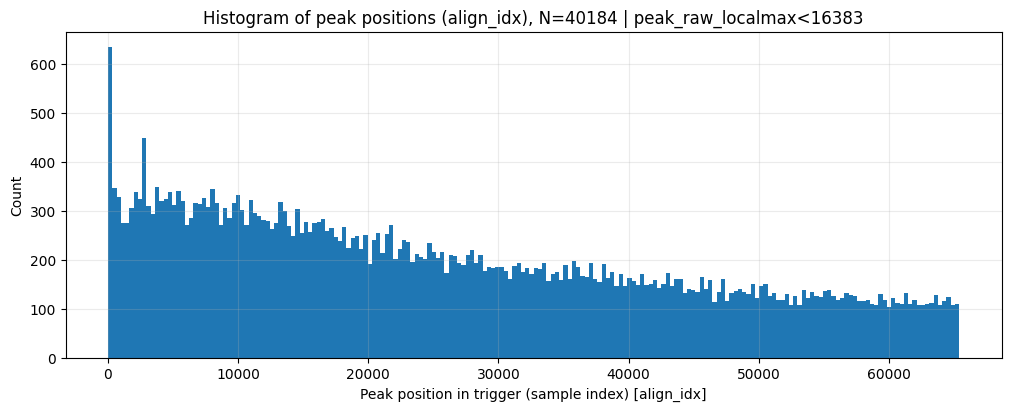

In [8]:
plot_peak_position_histogram(
    pulse_ds,
    use="align",
    bins=200,
    ADCsat=16383,
    sat_source="peak_raw_localmax"
);

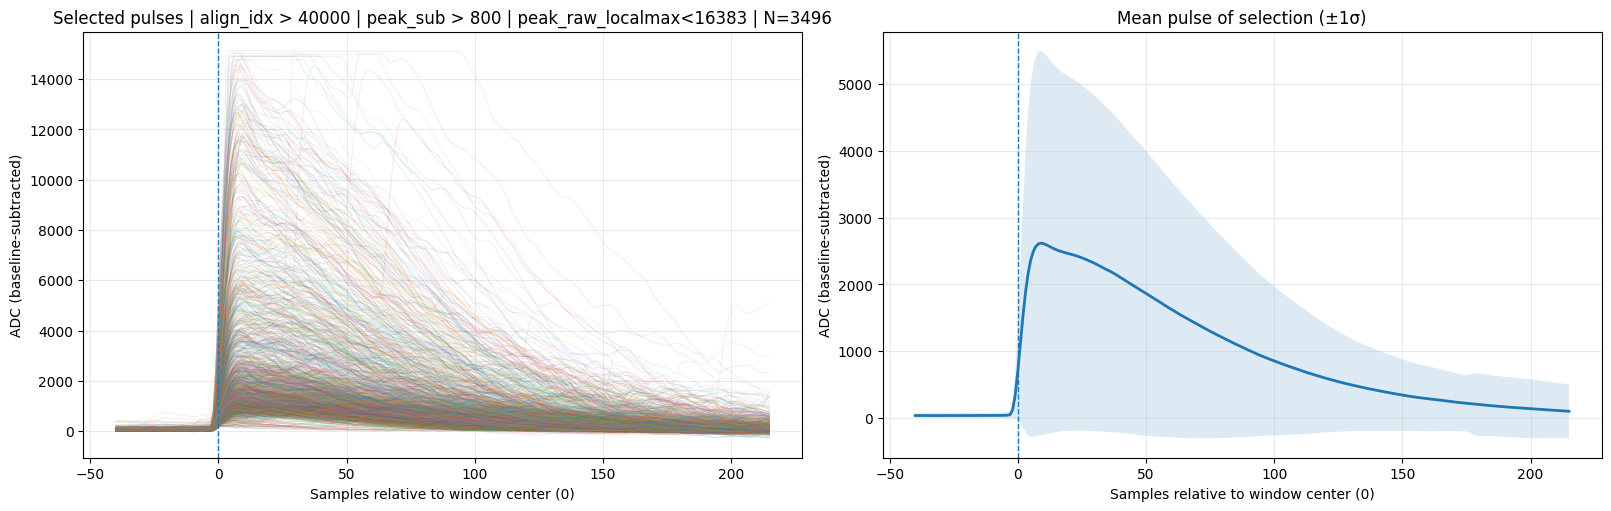

In [9]:
wins, meta = plot_pulses(
    pulse_ds,
    use_waveform="sub",
    use_pos="align",
    pos_side="after", pos_cut=40000,
    amp_side="above", amp_cut=800, amp_source="peak_sub",
    ADCsat=16383, sat_source="peak_raw_localmax",
    max_pulses_to_plot=1500,
);

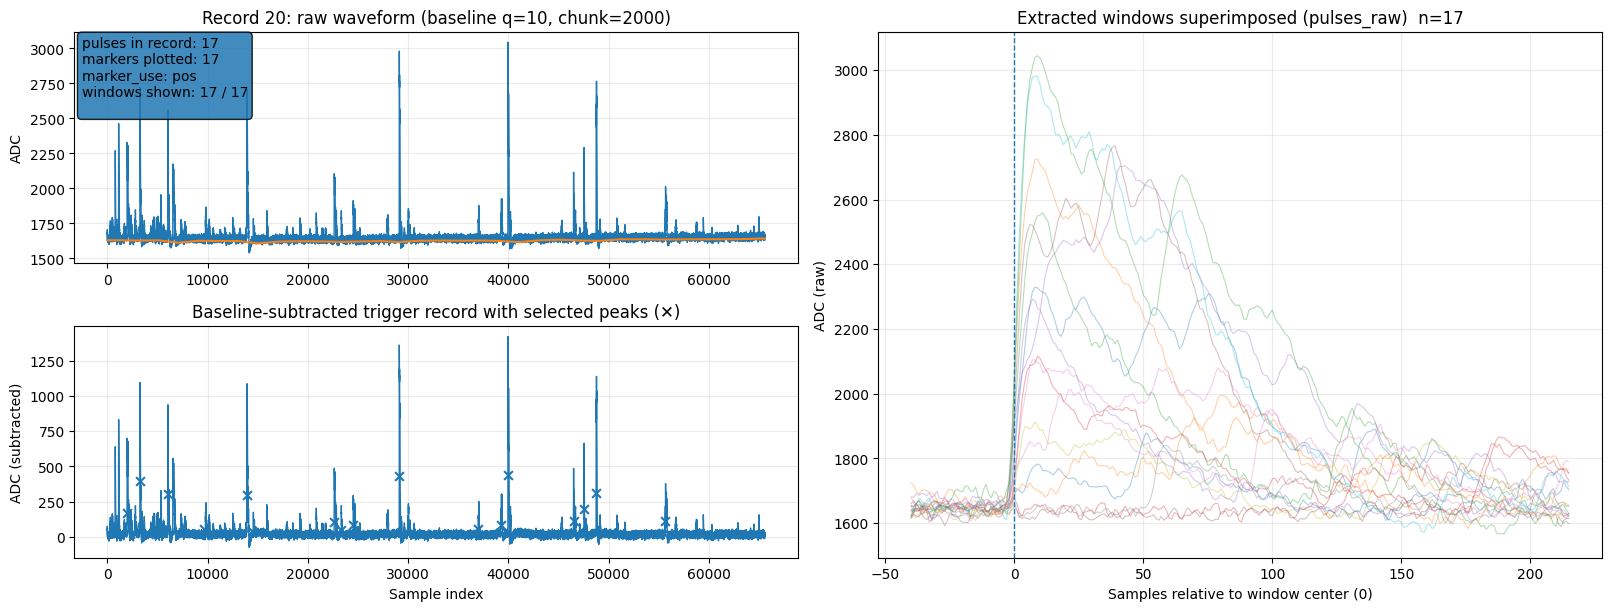

In [15]:
plot_record_qc_from_pulse_ds(
    X, pulse_ds,
    record_index=20,
    marker_use="pos",      # or "align_idx" / "peak_idx"
    use_windows="raw",     # or "sub"
    max_pulses_to_plot=200
);